# 🤖 TF-IDF and Logistic-Regression (Portfolio Chatbot — Intent Classification Model v2)
**Model:** TF-IDF + Logistic Regression  
**Author:** Aniket Das  
**Intents:** greeting, about, skills, projects, experience, education, certificates, contact, hiring, technology, thanks, goodbye, help

## 📦 Step 1 — Import Libraries

In [1]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import pandas as pd
import numpy as np
import pickle
import re
import os
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('omw-1.4',   quiet=True)

print('All libraries imported!')

All libraries imported!


## 📂 Step 2 — Load Dataset

In [2]:
df = pd.read_csv('../dataset/training_data.csv')

print(f'Total samples : {len(df)}')
print(f'Total intents : {df["intent"].nunique()}')
print(f'Intents       : {sorted(df["intent"].unique())}')
df.head(10)

Total samples : 1208
Total intents : 13
Intents       : ['about', 'certificates', 'contact', 'education', 'experience', 'goodbye', 'greeting', 'help', 'hiring', 'projects', 'skills', 'technology', 'thanks']


,text,intent
0,hi,greeting
1,hello,greeting
2,hey,greeting
3,hey there,greeting
4,hi there,greeting
5,good morning,greeting
6,good afternoon,greeting
7,good evening,greeting
8,what's up,greeting
9,howdy,greeting


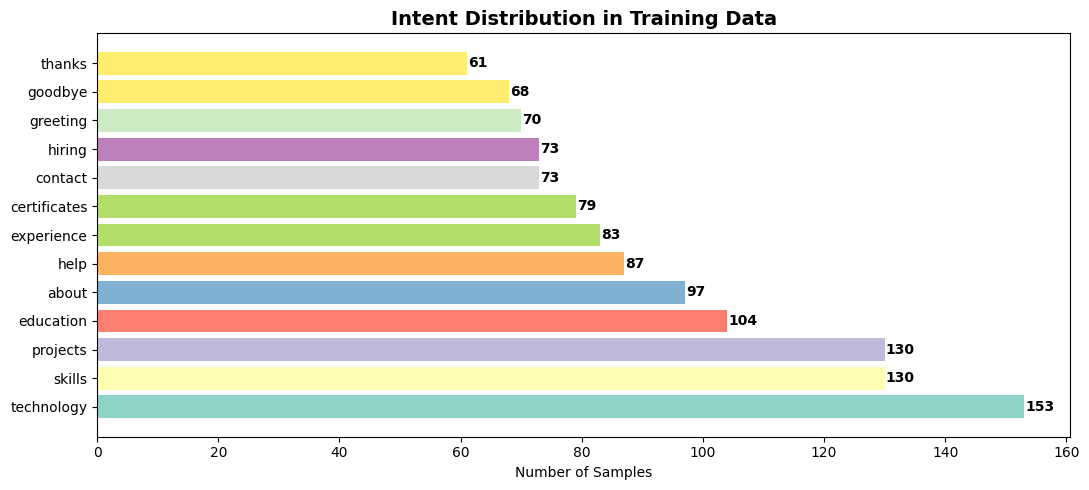

In [3]:
fig, ax = plt.subplots(figsize=(11, 5))
intent_counts = df['intent'].value_counts()
colors = plt.cm.Set3(np.linspace(0, 1, len(intent_counts)))
bars = ax.barh(intent_counts.index, intent_counts.values, color=colors)
ax.set_xlabel('Number of Samples')
ax.set_title('Intent Distribution in Training Data', fontsize=14, fontweight='bold')
for bar, val in zip(bars, intent_counts.values):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 🧹 Step 3 — Text Preprocessing

In [4]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english')) - {'not', 'no', 'what', 'how', 'where', 'which', 'who'}

def preprocess(text: str) -> str:
    text   = str(text).lower().strip()
    text   = re.sub(r"[^a-z0-9\s]", "", text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words]
    return " ".join(tokens)

df['processed'] = df['text'].apply(preprocess)

print('Before vs After preprocessing:\n')
print(df[['text', 'processed', 'intent']].head(15).to_string(index=False))

Before vs After preprocessing:

          text      processed   intent
            hi             hi greeting
         hello          hello greeting
           hey            hey greeting
     hey there            hey greeting
      hi there             hi greeting
  good morning   good morning greeting
good afternoon good afternoon greeting
  good evening   good evening greeting
     what's up          whats greeting
         howdy          howdy greeting
     greetings       greeting greeting
           sup            sup greeting
            yo             yo greeting
          hiya           hiya greeting
   hello there          hello greeting


## ✂️ Step 4 — Train / Test Split

In [5]:
X = df['processed']
y = df['intent']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples : {len(X_train)}')
print(f'Testing  samples : {len(X_test)}')

Training samples : 966
Testing  samples : 242


## 🏗️ Step 5 — Build & Train Pipeline

In [6]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=5000,
        sublinear_tf=True,
        min_df=1,
    )),
    ('clf', LogisticRegression(
        max_iter=1000,
        C=5.0,
        solver='lbfgs',
        multi_class='multinomial',
    ))
])

pipeline.fit(X_train, y_train)
print('Model trained successfully!')

Model trained successfully!


## 📊 Step 6 — Evaluate

In [7]:
y_pred = pipeline.predict(X_test)
print('Classification Report\n')
print(classification_report(y_test, y_pred))
print(f'Test Accuracy : {accuracy_score(y_test, y_pred):.3f}')

Classification Report

              precision    recall  f1-score   support

       about       0.63      0.63      0.63        19
certificates       0.86      0.75      0.80        16
     contact       1.00      0.73      0.85        15
   education       0.89      0.76      0.82        21
  experience       0.76      0.76      0.76        17
     goodbye       0.75      0.69      0.72        13
    greeting       0.89      0.57      0.70        14
        help       0.55      0.71      0.62        17
      hiring       0.91      0.67      0.77        15
    projects       0.92      0.92      0.92        26
      skills       0.76      0.73      0.75        26
  technology       0.59      0.87      0.70        31
      thanks       0.92      0.92      0.92        12

    accuracy                           0.76       242
   macro avg       0.80      0.75      0.77       242
weighted avg       0.79      0.76      0.76       242

Test Accuracy : 0.760


In [8]:
cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring='accuracy')
print(f'5-Fold CV : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')
print(f'Folds     : {[round(s,3) for s in cv_scores]}')

5-Fold CV : 0.708 ± 0.028
Folds     : [0.707, 0.678, 0.74, 0.676, 0.739]


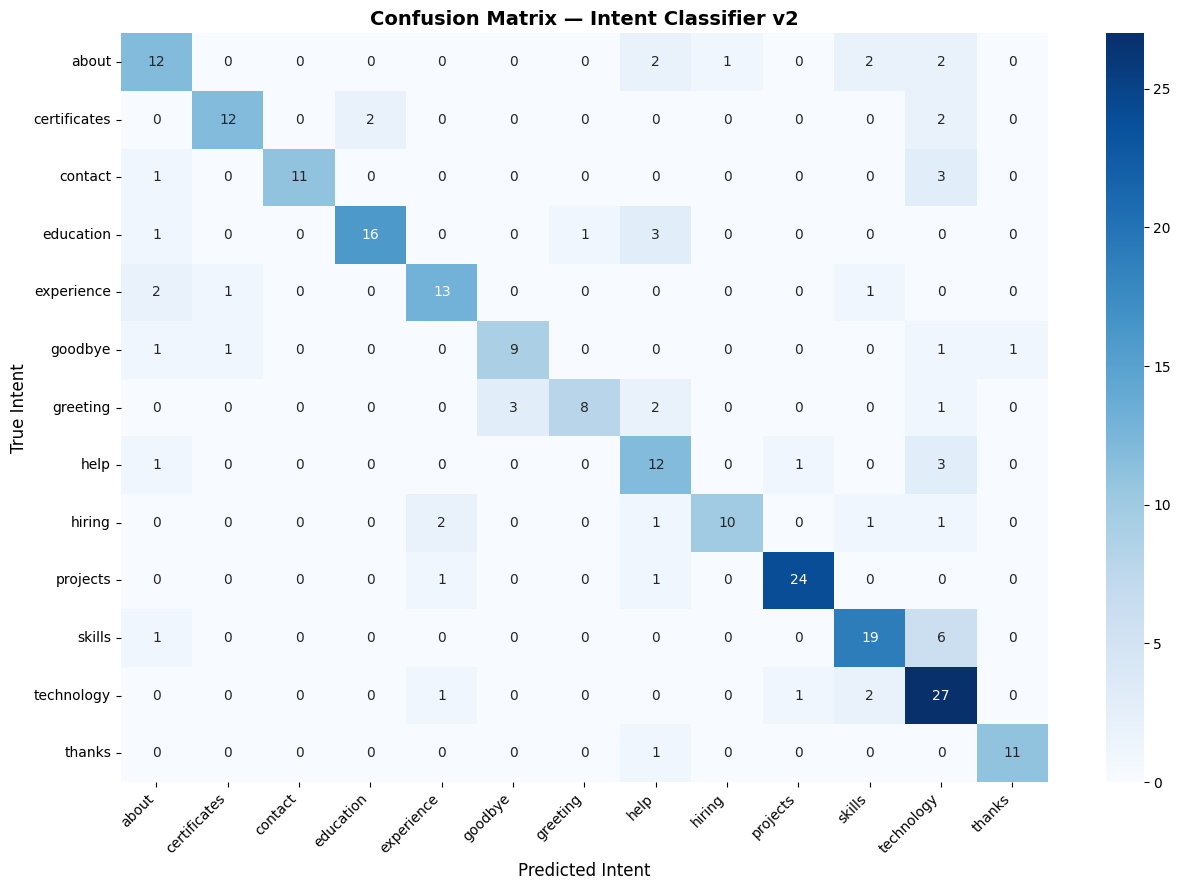

In [9]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(13, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_xlabel('Predicted Intent', fontsize=12)
ax.set_ylabel('True Intent', fontsize=12)
ax.set_title('Confusion Matrix — Intent Classifier v2', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 🔍 Step 7 — Smoke Test

In [10]:
test_messages = [
    "hey",
    "who are you",
    "tell me about yourself",
    "what skills do you have",
    "tell me about your projects",
    "tell me about chat buddies",
    "what is lunexa",
    "nextmart project",
    "how can i contact you",
    "are you open to work",
    "where did you study",
    "what certifications do you have",
    "tell me about sih hackathon",
    "do you know react",
    "webrtc experience",
    "thanks",
    "bye",
    "what can you do",
    "i want to hire you",
    "work experience",
]

print(f'{"Message":<40} {"Intent":<16} {"Confidence"}')
print('─' * 72)
for msg in test_messages:
    processed = preprocess(msg)
    proba     = pipeline.predict_proba([processed])[0]
    intent    = pipeline.classes_[proba.argmax()]
    conf      = proba.max()
    bar       = '█' * int(conf * 20)
    print(f'{msg:<40} {intent:<16} {conf:.2f}  {bar}')

Message                                  Intent           Confidence
────────────────────────────────────────────────────────────────────────
hey                                      greeting         0.97  ███████████████████
who are you                              technology       0.10  ██
tell me about yourself                   about            0.56  ███████████
what skills do you have                  skills           0.91  ██████████████████
tell me about your projects              projects         0.97  ███████████████████
tell me about chat buddies               projects         0.84  ████████████████
what is lunexa                           projects         0.76  ███████████████
nextmart project                         projects         0.97  ███████████████████
how can i contact you                    contact          0.76  ███████████████
are you open to work                     hiring           0.96  ███████████████████
where did you study                      education     

## 💾 Step 8 — Save Model

In [11]:
os.makedirs('../trainedmodel', exist_ok=True)

model_path = '../trainedmodel/intent_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(pipeline, f)

print(f'Model saved → {model_path}')

with open(model_path, 'rb') as f:
    loaded = pickle.load(f)

print(f'Load OK → "hello" → {loaded.predict([preprocess("hello")])[0]}')
print(f'Load OK → "who are you" → {loaded.predict([preprocess("who are you")])[0]}')
print(f'\n Intents saved: {list(pipeline.classes_)}')

Model saved → ../trainedmodel/intent_model.pkl
Load OK → "hello" → greeting
Load OK → "who are you" → technology

 Intents saved: ['about', 'certificates', 'contact', 'education', 'experience', 'goodbye', 'greeting', 'help', 'hiring', 'projects', 'skills', 'technology', 'thanks']


In [12]:
from sklearn.metrics import accuracy_score

y_pred = pipeline.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.3f} ({acc*100:.1f}%)")

Test Accuracy: 0.760 (76.0%)


In [13]:
from sklearn.model_selection import cross_val_score

cv = cross_val_score(pipeline, X, y, cv=5, scoring='accuracy')
print(f"CV Accuracy: {cv.mean():.3f} ± {cv.std():.3f}")

CV Accuracy: 0.708 ± 0.028
